# Catch Joe — Data Exploration

Exploratory analysis.  
Goal: understand the data distributions and identify patterns that can help fingerprint individual users.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

# ── Load dataset ───────────────────────────────────────────────────────────────
DATA_PATH = "../data/raw/dataset.json"

with open(DATA_PATH) as f:
    raw = json.load(f)

# ── Flatten to a session-level DataFrame ──────────────────────────────────────
records = []
for r in raw:
    records.append({
        "user_id":        r["user_id"],
        "browser":        r["browser"],
        "os":             r["os"],
        "locale":         r["locale"],
        "gender":         r["gender"],
        "country":        r["location"].split("/")[0],
        "city":           r["location"].split("/")[1],
        "date":           pd.to_datetime(r["date"]),
        "time":           r["time"],
        "n_sites":        len(r["sites"]),
        "total_time":     sum(s["length"] for s in r["sites"]),
        "mean_site_time": np.mean([s["length"] for s in r["sites"]]),
        "sites":          [s["site"] for s in r["sites"]],
        "lengths":        [s["length"] for s in r["sites"]],
    })

df = pd.DataFrame(records)
df["hour"]       = df["time"].str.split(":").str[0].astype(int)
df["day_of_week"] = df["date"].dt.day_name()
df["year_month"] = df["date"].dt.to_period("M")

print(f"Sessions : {len(df):,}")
print(f"Users    : {df.user_id.nunique()}")
print(f"Date span: {df.date.min().date()} → {df.date.max().date()}")
df.head(3)

Sessions : 160,000
Users    : 200
Date span: 2016-01-14 → 2019-06-18


,user_id,browser,os,locale,gender,country,city,date,time,n_sites,total_time,mean_site_time,sites,lengths,hour,day_of_week,year_month
0,164,Chrome,Windows 8,de-DE,m,Canada,Toronto,2016-08-14,03:57:00,14,1839,131.357143,"[lenta.ru, lenta.ru, vk.com, lenta.ru, wikiped...","[296, 69, 94, 129, 70, 120, 54, 213, 140, 166,...",3,Sunday,2016-08
1,99,Chrome,Windows 10,pt-PT,f,Netherlands,Amsterdam,2016-05-31,13:52:00,12,1430,119.166667,"[windowsupdate.com, amazon.com, live.com, akam...","[56, 413, 64, 60, 99, 63, 50, 41, 60, 55, 252,...",13,Tuesday,2016-05
2,28,Chrome,Windows 10,bg-BG,m,Brazil,Rio de Janeiro,2019-04-15,17:40:00,12,1142,95.166667,"[slack.com, slack.com, mail.google.com, vk.com...","[158, 153, 43, 63, 121, 138, 64, 41, 65, 149, ...",17,Monday,2019-04


## 1 · Dataset Overview

In [22]:
print("Numeric summary")
df[["n_sites", "total_time", "mean_site_time"]].describe().round(2)

Numeric summary


,n_sites,total_time,mean_site_time
count,160000.00,160000.0,160000.00
mean,12.91,1672.5,129.55
std,2.19,430.4,25.68
min,1.00,45.0,45.00
25%,12.00,1397.0,111.47
50%,13.00,1669.0,127.13
75%,15.00,1948.0,145.00
max,15.00,3888.0,459.00


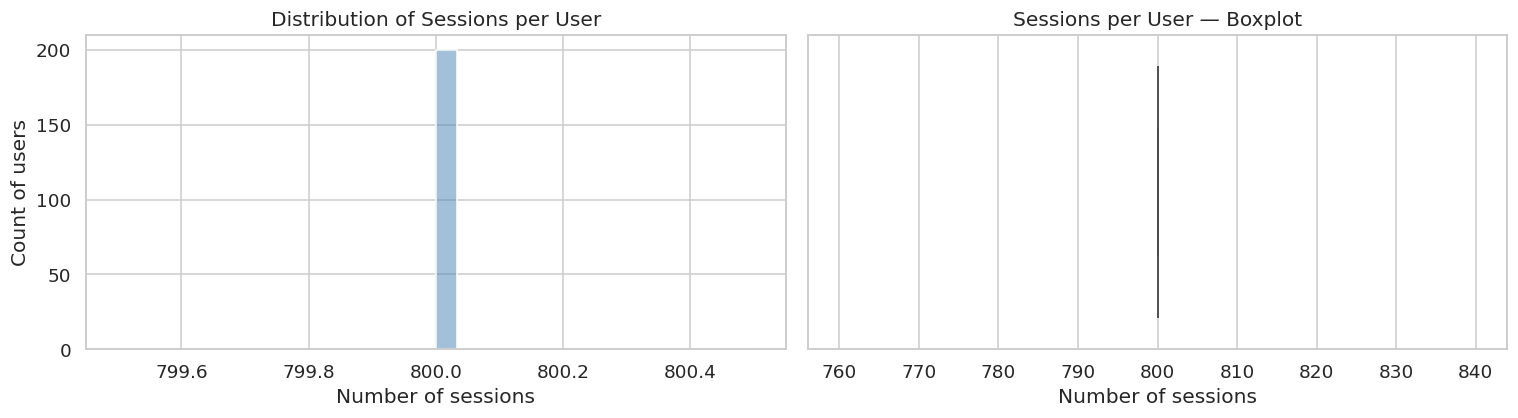

count    200.0
mean     800.0
std        0.0
min      800.0
25%      800.0
50%      800.0
75%      800.0
max      800.0
Name: sessions, dtype: float64


In [21]:
# Sessions per user distribution
sessions_per_user = df.groupby("user_id").size().reset_index(name="sessions")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(sessions_per_user["sessions"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Sessions per User")
axes[0].set_xlabel("Number of sessions")
axes[0].set_ylabel("Count of users")

sns.boxplot(x=sessions_per_user["sessions"], ax=axes[1], color="steelblue")
axes[1].set_title("Sessions per User — Boxplot")
axes[1].set_xlabel("Number of sessions")

plt.tight_layout()
plt.show()
print(sessions_per_user["sessions"].describe().round(1))

## 2 · User Demographics

/tmp/ipykernel_62177/1616068467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=ax, palette="tab10")
/tmp/ipykernel_62177/1616068467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=ax, palette="tab10")
/tmp/ipykernel_62177/1616068467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=ax, palette="tab10")


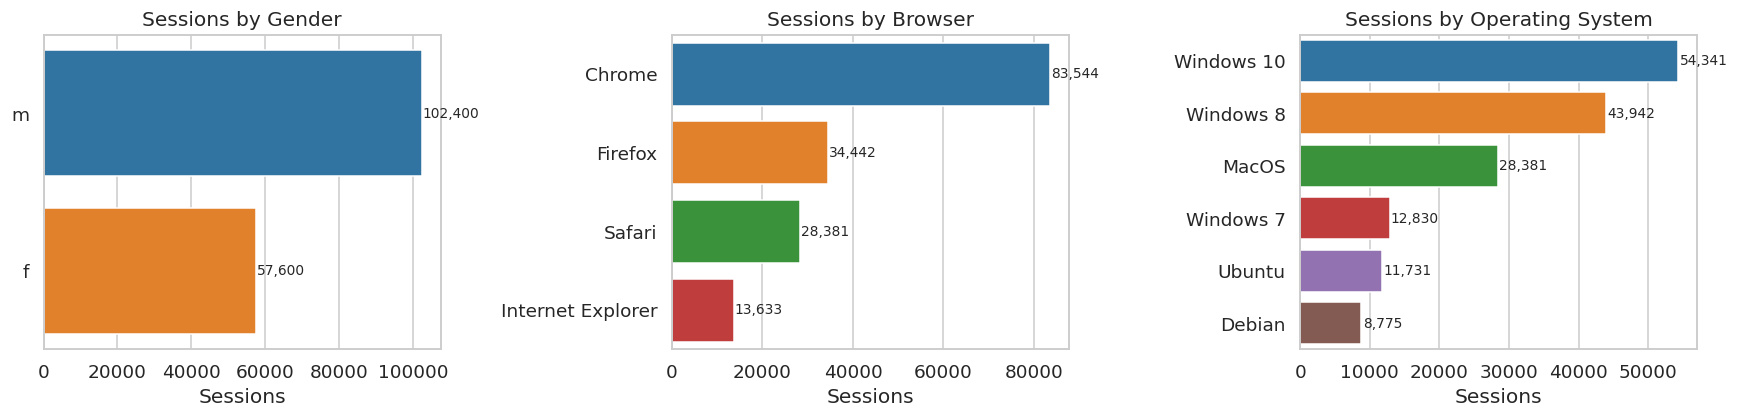

In [4]:
# Gender, Browser, OS — count plots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(
    axes,
    ["gender", "browser", "os"],
    ["Gender", "Browser", "Operating System"],
):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, palette="tab10")
    ax.set_title(f"Sessions by {title}")
    ax.set_xlabel("Sessions")
    ax.set_ylabel("")
    for bar in ax.patches:
        ax.text(
            bar.get_width() + 200,
            bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}",
            va="center", fontsize=9,
        )

plt.tight_layout()
plt.show()

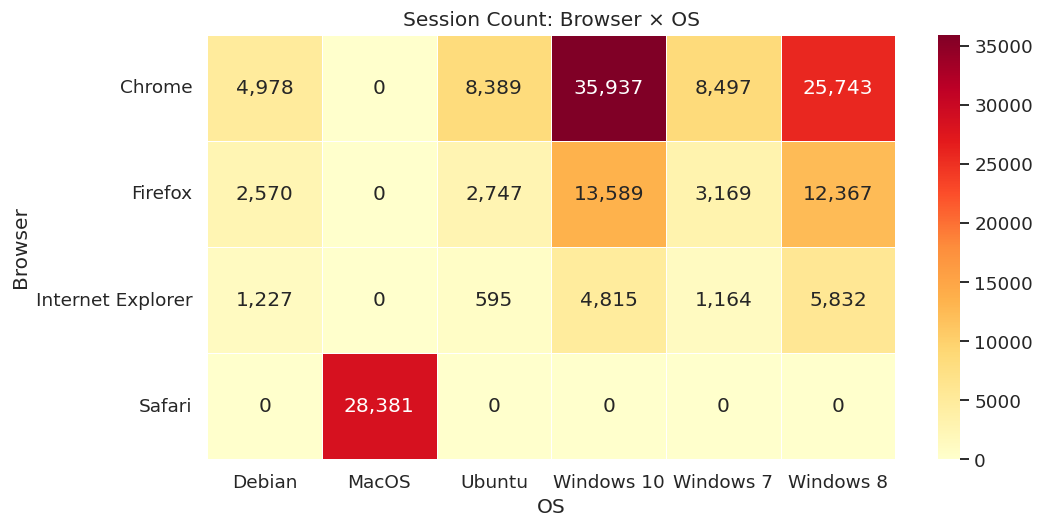

In [5]:
# Browser × OS heatmap (share of sessions)
pivot_browser_os = (
    df.groupby(["browser", "os"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_browser_os,
    annot=True, fmt=",d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Session Count: Browser × OS")
ax.set_xlabel("OS")
ax.set_ylabel("Browser")
plt.tight_layout()
plt.show()

/tmp/ipykernel_62177/496949283.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis", ax=ax)


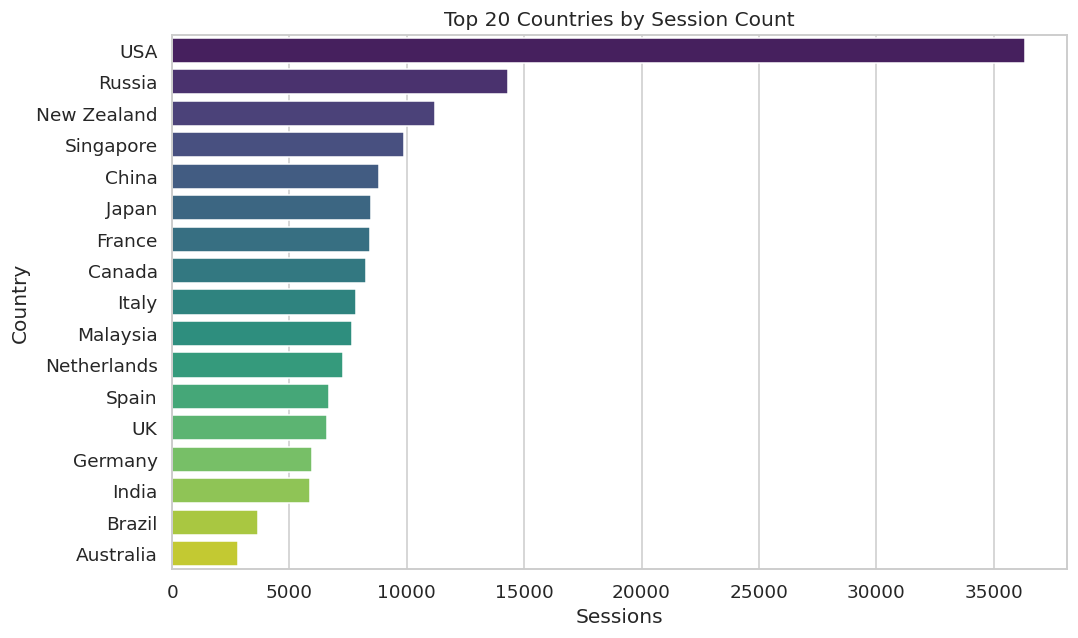

In [23]:
# Top-20 countries by session count
top_countries = df["country"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis", ax=ax)
ax.set_title("Top 20 Countries by Session Count")
ax.set_xlabel("Sessions")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

/tmp/ipykernel_62177/4013840384.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locales.values, y=top_locales.index, palette="mako", ax=ax)


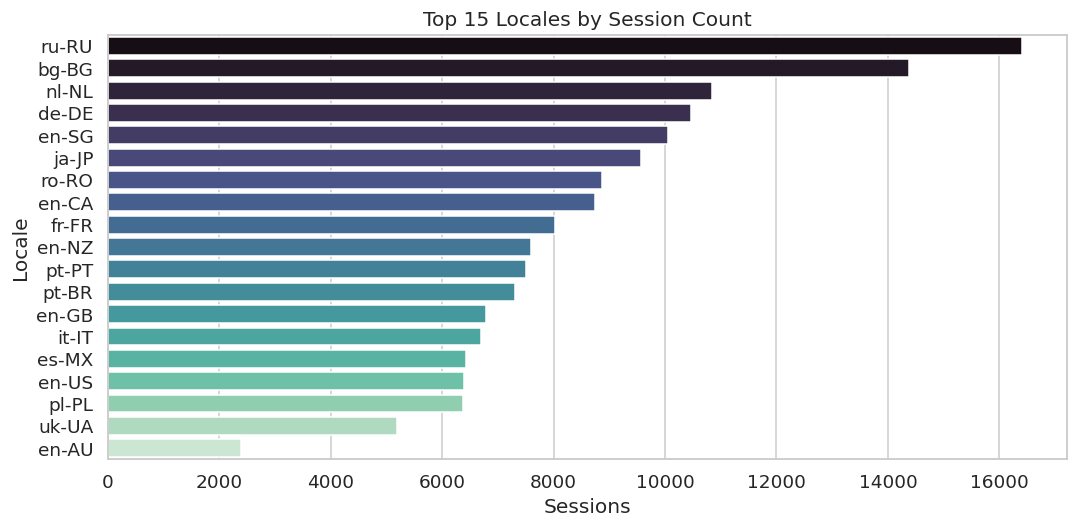

In [24]:
# Top-15 locales
top_locales = df["locale"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_locales.values, y=top_locales.index, palette="mako", ax=ax)
ax.set_title("Top 15 Locales by Session Count")
ax.set_xlabel("Sessions")
ax.set_ylabel("Locale")
plt.tight_layout()
plt.show()

## 3 · Temporal Patterns

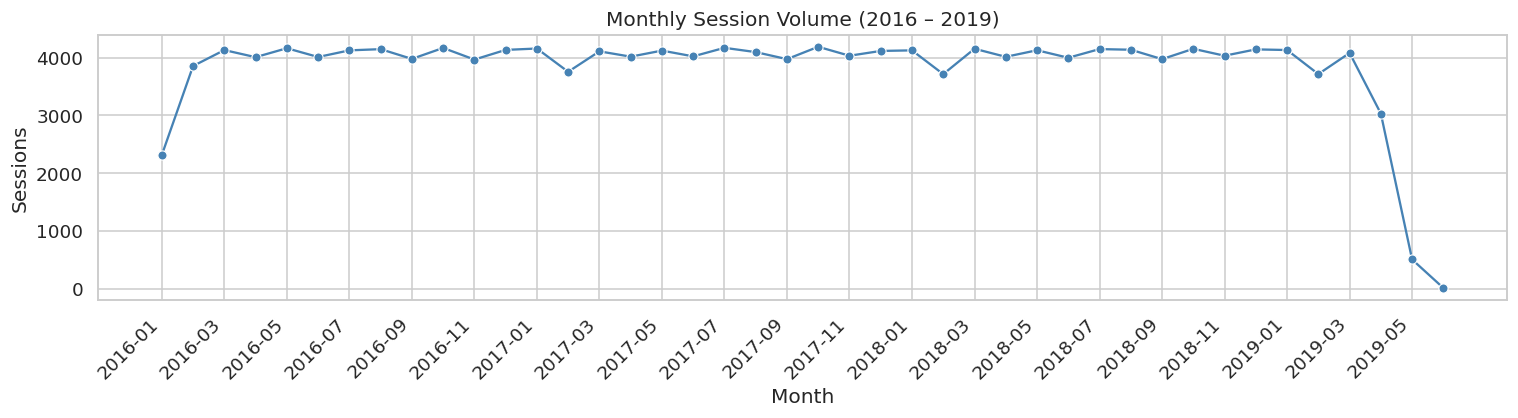

In [8]:
# Sessions over time (monthly)
monthly = df.groupby("year_month").size().reset_index(name="sessions")
monthly["year_month_str"] = monthly["year_month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(data=monthly, x="year_month_str", y="sessions", marker="o", color="steelblue", ax=ax)
ax.set_title("Monthly Session Volume (2016 – 2019)")
ax.set_xlabel("Month")
ax.set_ylabel("Sessions")
tick_step = max(1, len(monthly) // 20)
ax.set_xticks(ax.get_xticks()[::tick_step])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_62177/839739585.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hour_counts.index, y=hour_counts.values, palette="coolwarm", ax=axes[0])


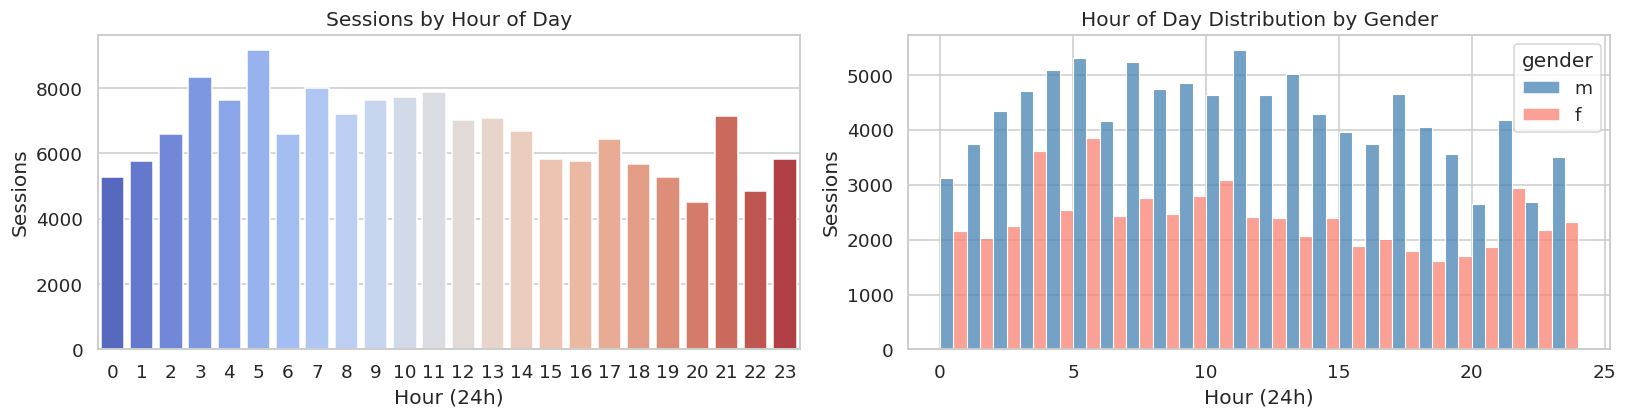

In [9]:
# Hour-of-day distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

hour_counts = df["hour"].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values, palette="coolwarm", ax=axes[0])
axes[0].set_title("Sessions by Hour of Day")
axes[0].set_xlabel("Hour (24h)")
axes[0].set_ylabel("Sessions")

# Hour by gender
sns.histplot(data=df, x="hour", hue="gender", multiple="dodge",
             bins=24, binrange=(0, 24), stat="count",
             palette={"m": "steelblue", "f": "salmon"}, ax=axes[1])
axes[1].set_title("Hour of Day Distribution by Gender")
axes[1].set_xlabel("Hour (24h)")
axes[1].set_ylabel("Sessions")

plt.tight_layout()
plt.show()

/tmp/ipykernel_62177/2944413323.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_counts.index, y=dow_counts.values, palette="Spectral", ax=ax)


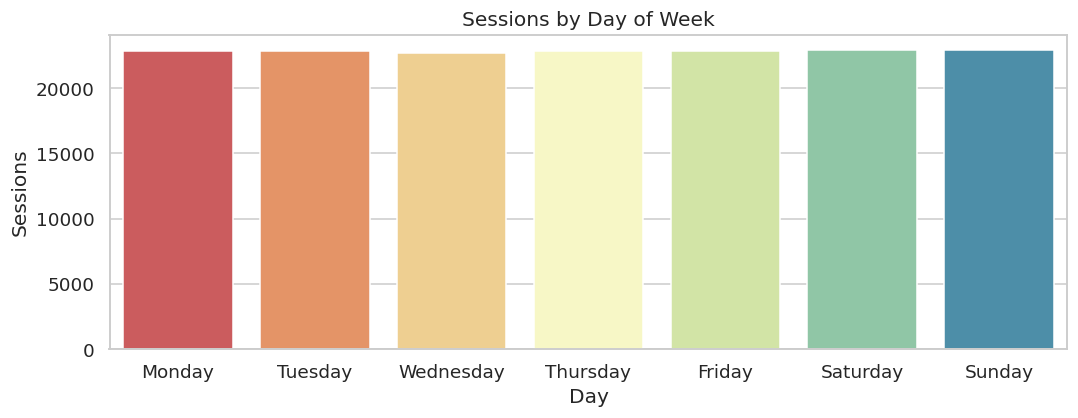

In [10]:
# Day-of-week session counts
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = df["day_of_week"].value_counts().reindex(dow_order)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=dow_counts.index, y=dow_counts.values, palette="Spectral", ax=ax)
ax.set_title("Sessions by Day of Week")
ax.set_xlabel("Day")
ax.set_ylabel("Sessions")
plt.tight_layout()
plt.show()

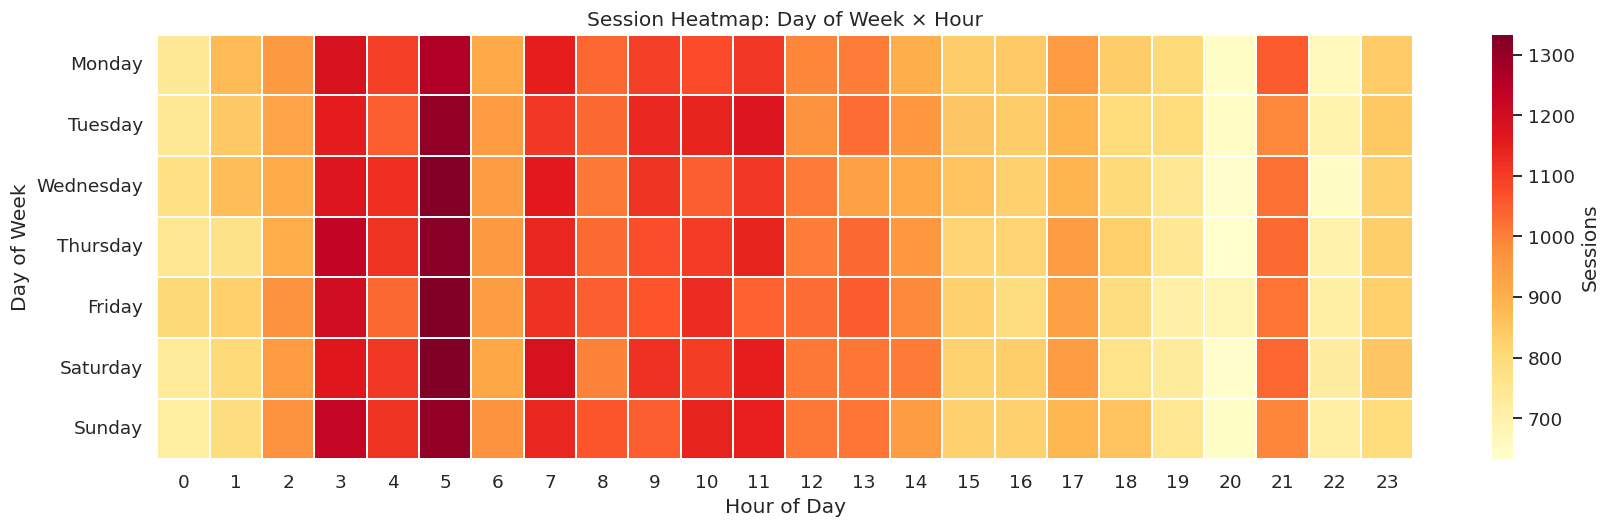

In [11]:
# Hour × Day-of-week heatmap (average sessions)
pivot_time = (
    df.groupby(["day_of_week", "hour"])
    .size()
    .unstack(fill_value=0)
    .reindex(dow_order)
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot_time, cmap="YlOrRd", linewidths=0.3, ax=ax, cbar_kws={"label": "Sessions"})
ax.set_title("Session Heatmap: Day of Week × Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")
plt.tight_layout()
plt.show()

## 4 · Browsing Behaviour

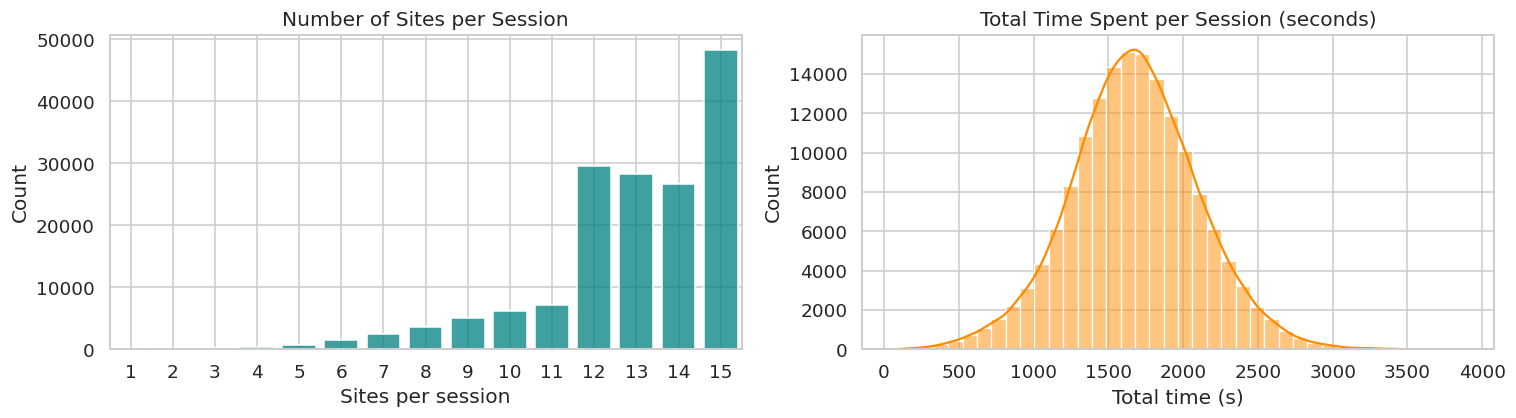

In [29]:
# Sites per session & total session time distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["n_sites"], discrete=True, color="teal", shrink=0.8, ax=axes[0])
axes[0].set_title("Number of Sites per Session")
axes[0].set_xlabel("Sites per session")
axes[0].set_ylabel("Count")
axes[0].set_xticks(range(df["n_sites"].min(), df["n_sites"].max() + 1))
axes[0].set_xlim(df["n_sites"].min() - 0.5, df["n_sites"].max() + 0.5)

sns.histplot(df["total_time"], bins=40, kde=True, color="darkorange", ax=axes[1])
axes[1].set_title("Total Time Spent per Session (seconds)")
axes[1].set_xlabel("Total time (s)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

/tmp/ipykernel_62177/1509310186.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="browser", y="mean_site_time", palette="Set2",
/tmp/ipykernel_62177/1509310186.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="os", y="mean_site_time", palette="Set3",


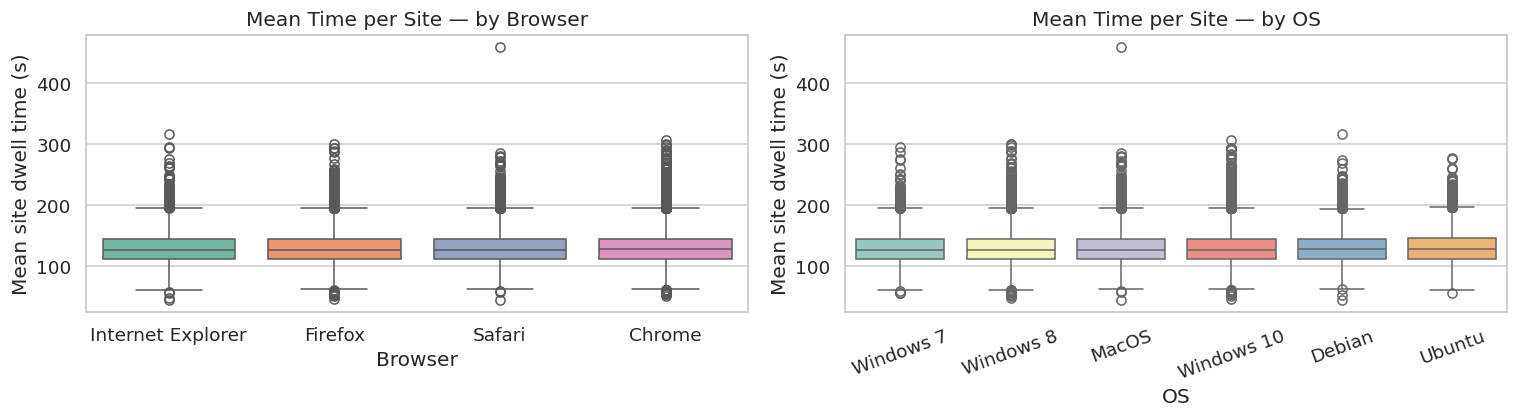

In [13]:
# Mean time per site — by browser and OS
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df, x="browser", y="mean_site_time", palette="Set2",
            order=df.groupby("browser")["mean_site_time"].median().sort_values().index,
            ax=axes[0])
axes[0].set_title("Mean Time per Site — by Browser")
axes[0].set_xlabel("Browser")
axes[0].set_ylabel("Mean site dwell time (s)")

sns.boxplot(data=df, x="os", y="mean_site_time", palette="Set3",
            order=df.groupby("os")["mean_site_time"].median().sort_values().index,
            ax=axes[1])
axes[1].set_title("Mean Time per Site — by OS")
axes[1].set_xlabel("OS")
axes[1].set_ylabel("Mean site dwell time (s)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

/tmp/ipykernel_62177/2831794131.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top30, x="visits", y="site", palette="flare", ax=ax)


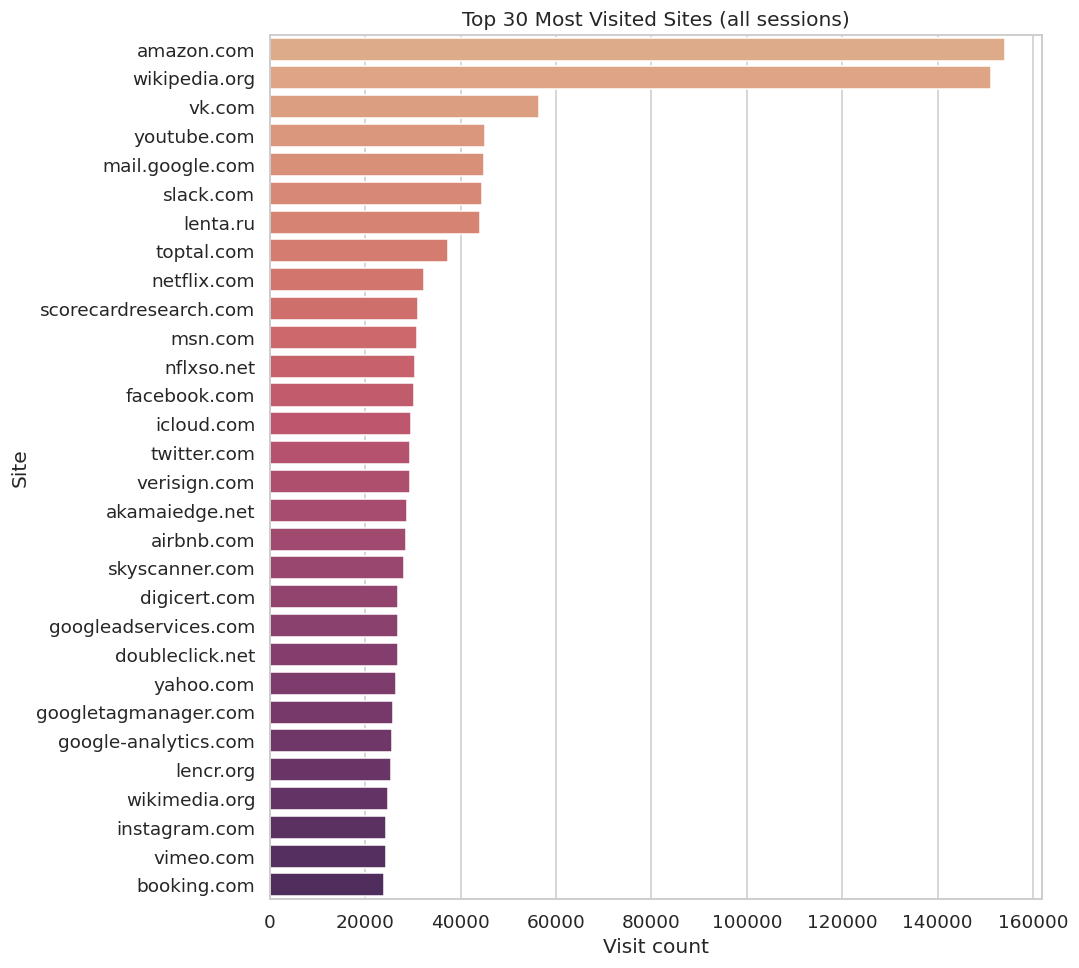

In [14]:
# Top-30 most visited sites
all_sites = [s for sites in df["sites"] for s in sites]
site_counts = Counter(all_sites)
top30 = pd.DataFrame(site_counts.most_common(30), columns=["site", "visits"])

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=top30, x="visits", y="site", palette="flare", ax=ax)
ax.set_title("Top 30 Most Visited Sites (all sessions)")
ax.set_xlabel("Visit count")
ax.set_ylabel("Site")
plt.tight_layout()
plt.show()

/tmp/ipykernel_62177/15767936.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=site_dwell_df, x="site", y="length", order=order,


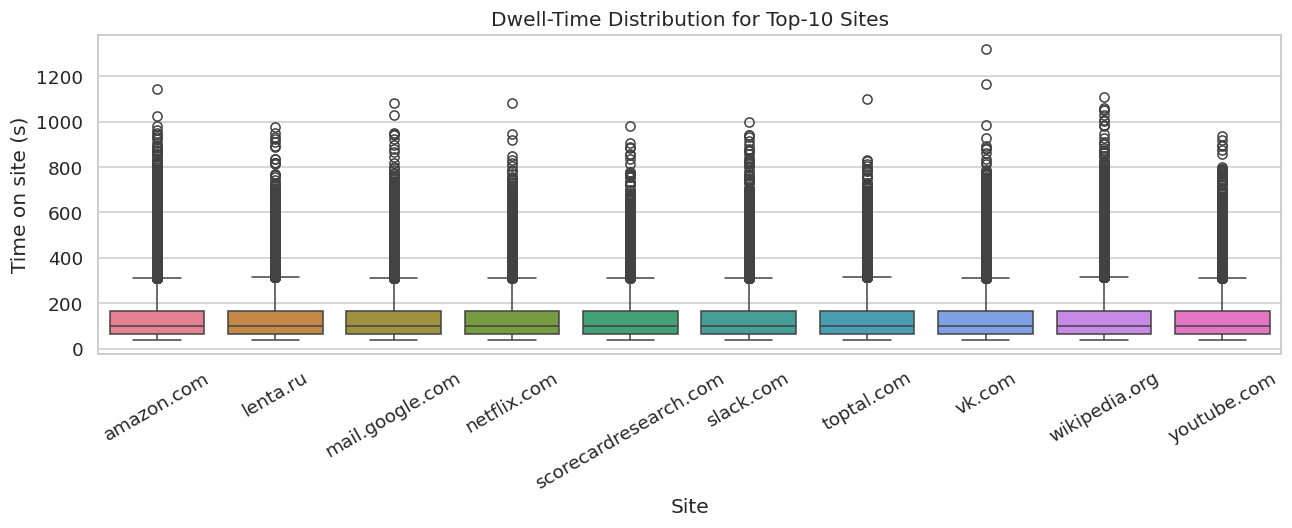

In [15]:
# Individual site dwell-time distribution (top-10 sites)
top10_sites = [s for s, _ in site_counts.most_common(10)]

site_dwell = []
for r in raw:
    for entry in r["sites"]:
        if entry["site"] in top10_sites:
            site_dwell.append({"site": entry["site"], "length": entry["length"]})

site_dwell_df = pd.DataFrame(site_dwell)

fig, ax = plt.subplots(figsize=(12, 5))
order = site_dwell_df.groupby("site")["length"].median().sort_values(ascending=False).index
sns.boxplot(data=site_dwell_df, x="site", y="length", order=order,
            palette="husl", ax=ax)
ax.set_title("Dwell-Time Distribution for Top-10 Sites")
ax.set_xlabel("Site")
ax.set_ylabel("Time on site (s)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 5 · Per-User Behavioural Fingerprints

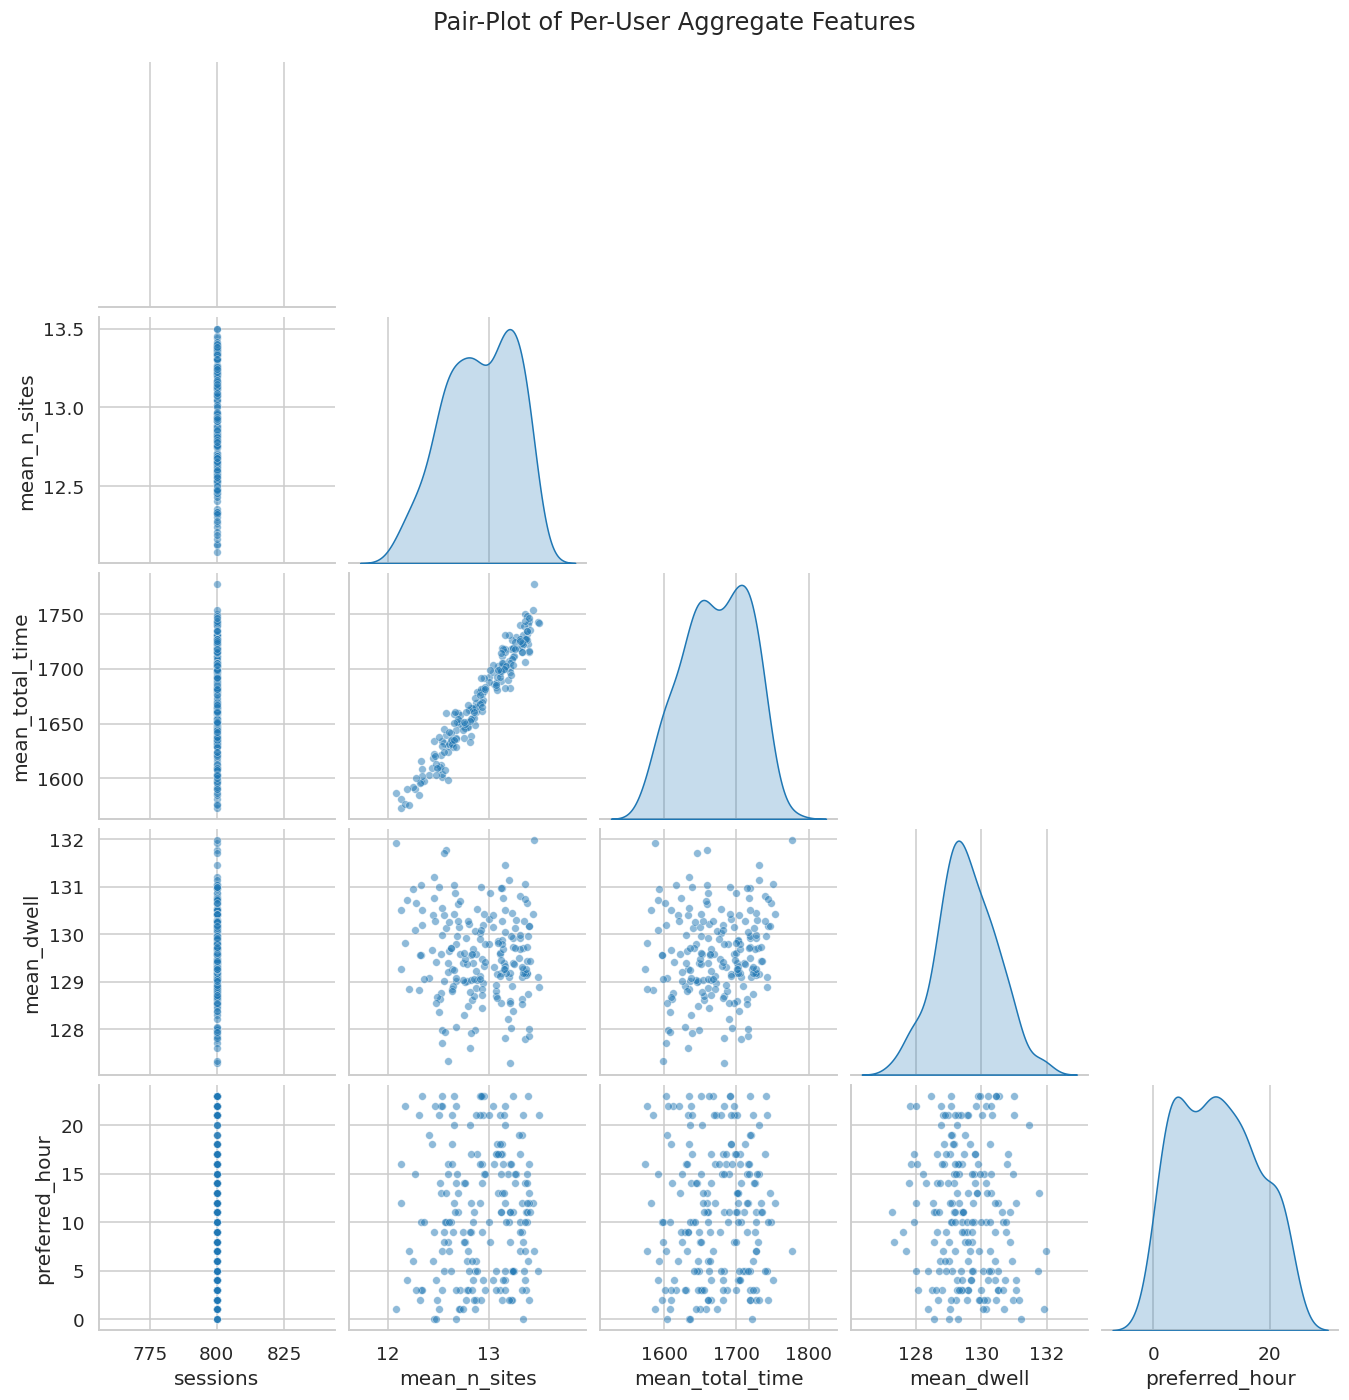

In [30]:
# Per-user aggregate stats
user_stats = df.groupby("user_id").agg(
    sessions=("user_id", "count"),
    mean_n_sites=("n_sites", "mean"),
    mean_total_time=("total_time", "mean"),
    mean_dwell=("mean_site_time", "mean"),
    preferred_hour=("hour", lambda x: x.mode()[0]),
).reset_index()

# Pair-plot of user-level features
g = sns.pairplot(
    user_stats[["sessions", "mean_n_sites", "mean_total_time", "mean_dwell", "preferred_hour"]],
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 25},
    diag_kws={"fill": True},
    corner=True
)
g.figure.suptitle("Pair-Plot of Per-User Aggregate Features", y=1.02)
plt.show()

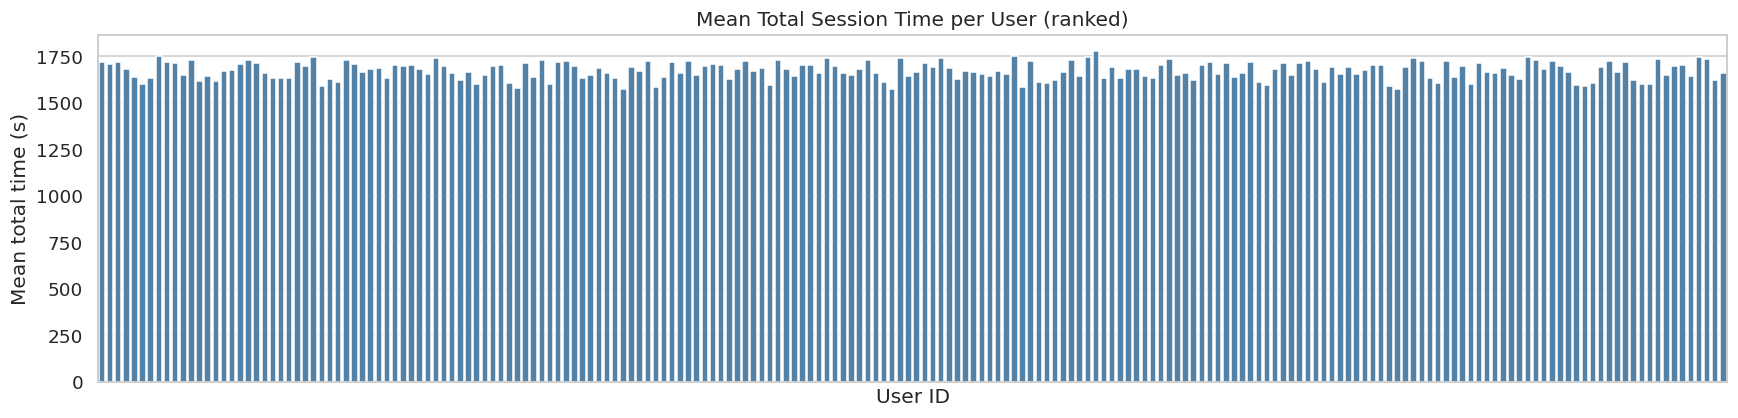

In [17]:
# Mean total session time per user — ranked bar chart
user_time_ranked = user_stats.sort_values("mean_total_time", ascending=False)

fig, ax = plt.subplots(figsize=(16, 4))
sns.barplot(data=user_time_ranked, x="user_id", y="mean_total_time",
            color="steelblue", ax=ax)
ax.set_title("Mean Total Session Time per User (ranked)")
ax.set_xlabel("User ID")
ax.set_ylabel("Mean total time (s)")
ax.set_xticks([])          # too many ticks → suppress
plt.tight_layout()
plt.show()

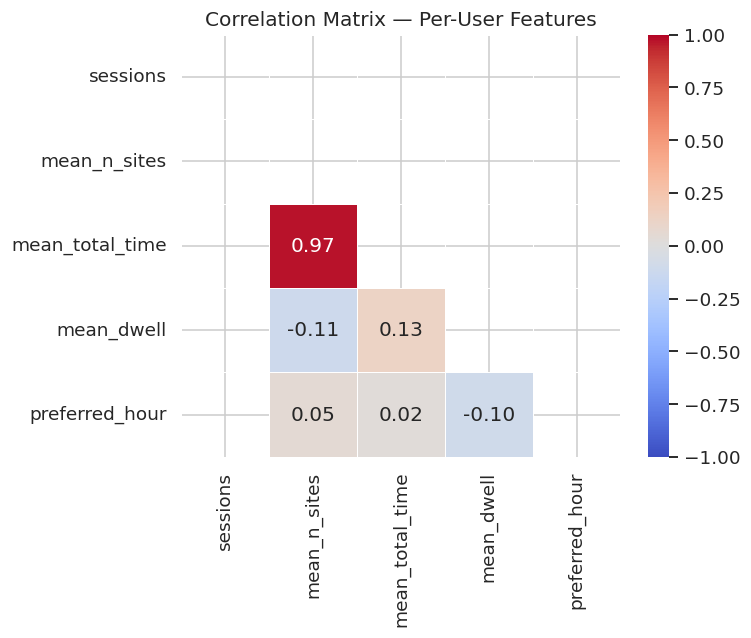

In [18]:
# Correlation heatmap of user-level features
corr = user_stats[["sessions", "mean_n_sites", "mean_total_time", "mean_dwell", "preferred_hour"]].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Per-User Features")
plt.tight_layout()
plt.show()

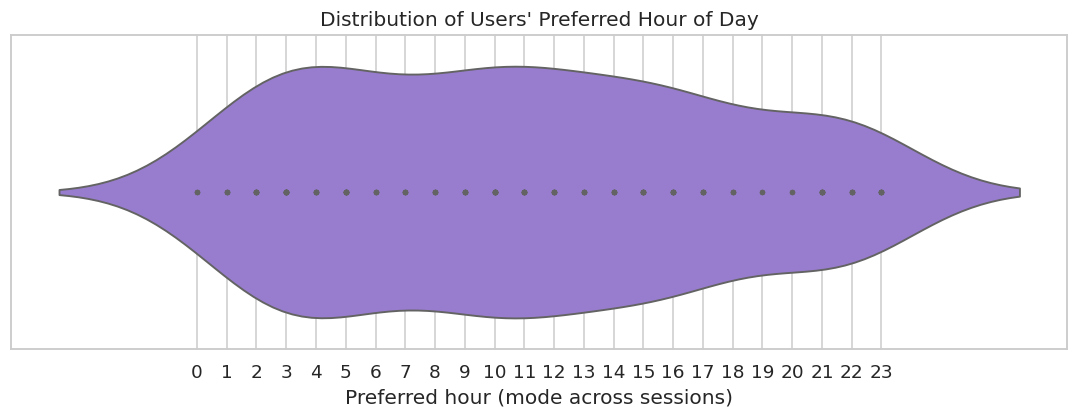

In [19]:
# Per-user preferred browsing hour — strip/violin plot
fig, ax = plt.subplots(figsize=(10, 4))
sns.violinplot(x=user_stats["preferred_hour"], inner="point",
               color="mediumpurple", ax=ax)
ax.set_title("Distribution of Users' Preferred Hour of Day")
ax.set_xlabel("Preferred hour (mode across sessions)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

/tmp/ipykernel_62177/412652016.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=unique_users_per_site, x="unique_users", y="site",


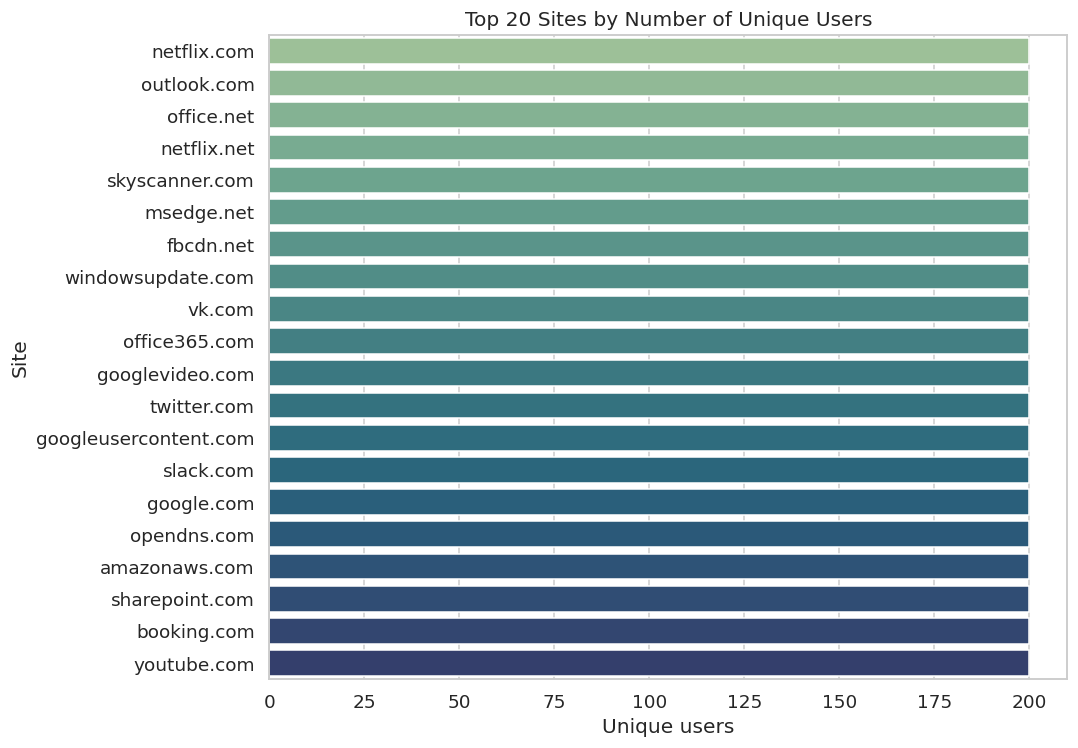

In [20]:
# Top-20 sites by unique users who visited them
site_user = []
for r in raw:
    uid = r["user_id"]
    for entry in r["sites"]:
        site_user.append({"user_id": uid, "site": entry["site"]})

site_user_df = pd.DataFrame(site_user).drop_duplicates()
unique_users_per_site = (
    site_user_df.groupby("site")["user_id"].nunique()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="unique_users")
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=unique_users_per_site, x="unique_users", y="site",
            palette="crest", ax=ax)
ax.set_title("Top 20 Sites by Number of Unique Users")
ax.set_xlabel("Unique users")
ax.set_ylabel("Site")
plt.tight_layout()
plt.show()